In [4]:
!pip install nltk
import nltk
nltk.download('vader_lexicon')


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [5]:
!pip install vaderSentiment

In [6]:
# prompt: from Shoe_Data.csv please import data in a a list of dictionaries
import csv
reviews = []

with open('Shoes_Data.csv', 'r', encoding='utf-8') as file:
    reader = csv.DictReader(file)
    shoes_data = [row for row in reader]

# print(shoes_data)
for item in shoes_data:

  if 'reviews' in item:
    # print(item['reviews'])
    review = item['reviews']
    review = review.replace('\n', '.').replace('!' , '.').replace('||', '.')
    # print(review)
    tmp = review.strip().split('.')

    tmp = [t for t in tmp if t != '' ]
    if not tmp in reviews:
      reviews.append(tmp)

for review in reviews:
    print(review)


['Not happy with product', " It's not as expected", ' AVERAGE PRODUCT', ' Pic more beautiful', ' Got damage product', ' But quality is average for 300₹', ' Bad product different from what was listed', ' Worst product', " Don't buy", ' Low quality makes pain on heals by sharp edges inside shoes', ' Do not buy it anyway']
['Memory cushioning in these shoes is the best feature', ' Poor quality product', ' Best for gym n sports', ' Must must must buy', ' Worth for this price', ' Satisfied', ' Please try this shoe', ' Very good for heels', ' Comfy cushion', ' Good lookinggood quality not exact fit a bit over sized', ' Awesome Amazon Awesome']
['Worth to its amount', ' Go for it', ' Perfect', ' 5 star', ' Itam not received', ' Worst product ', 'please dont buy', ' Nice Shoes', ' Pros and cons', ' No buy', ' Ignore this and go for another option']
['Sup quality', ' Good but not expected', ' Awesome 👌']
['Best', ' Satisfied', ' Affordable beauty 😘😘😘😘 the eye catcher 😊', ' Economical and soft f

In [7]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
analyzer = SentimentIntensityAnalyzer()

# Analyze the sentiment for sentences in each review
Negative_reviews = []
for review in reviews:
  negative_sent = []
  for sentence in review:
    sentiment = analyzer.polarity_scores(sentence)

    if sentiment['compound'] < 0 and sentiment['neu'] < 0.9:
      negative_sent.append(sentence)
  Negative_reviews.append(negative_sent)

for review in Negative_reviews:
  if review:
    print(review)



['Not happy with product', ' Got damage product', ' Bad product different from what was listed', ' Worst product', ' Low quality makes pain on heals by sharp edges inside shoes']
[' Poor quality product']
[' Worst product ', ' No buy', ' Ignore this and go for another option']
[' You get what you pay for']
[' Poor quality product', ' Bad']
[' Poor quality', 'poor quality']
[" Very poor product don't buy it", ' Worst worst worst', ' Poor quality']
[' How can you cheat with customer you erase size number back side of shoes']
[' Total Fake', ' Disappointed', ' Pathetic Product ', ' Poor quality', " Worst packaging size doesn't fits well"]
['1 no', ' Not worth the price', ' Pathetic']
[' Bad Quality', ' I dont like thik', ' Very very disastrous quality', ' Bad quantity', " Very bad quality product Don't buy"]
['Poor Build quality avoid it']
['is Bad', ' Pasting not good']
['Quality is not good  and size is not ok delivered', ' Poor quality', ' Bad products', ' Very waste']
['Looking good b

In [8]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import string

# # Download required NLTK resources
# nltk.download('words')
# nltk.download('punkt')
# nltk.download('wordnet')
# nltk.download('averaged_perceptron_tagger')
# nltk.download('stopwords')

lemmatizer = WordNetLemmatizer()

def preprocess(text):
    # Lowercase text
    text = text.lower()
    # Tokenize text
    words = word_tokenize(text)
    # Remove non-English words
    words = [word for word in words if word in english_words]
    # POS tagging
    words_pos = nltk.pos_tag(words)
    # Lemmatization
    words = [lemmatizer.lemmatize(word, pos='n') for word, pos in words_pos]
    # Eliminate words excluding nouns
    words = [word for word, pos in words_pos if pos.startswith('NN')]
    # Remove stop words
    words = [word for word in words if word not in stopwords.words('english')]
    # Remove punctuation
    words = [word for word in words if word not in string.punctuation]
    # Remove numbers
    words = [word for word in words if not word.isdigit()]
    # Remove empty and one-letter words
    words = [word for word in words if len(word) > 1]

    return words

preprocessed_reviews = []
english_words = set(nltk.corpus.words.words())
for review_list in Negative_reviews:
    if review_list:
        processed_list = [preprocess(review) for review in review_list]
        tmp = []
        for item in processed_list:
          if item:
            tmp.append(item)
        preprocessed_reviews.append(tmp)

    else:
        preprocessed_reviews.append(review_list)

for review in preprocessed_reviews:
    print(review)


[['product'], ['damage', 'product'], ['product'], ['product'], ['quality', 'pain', 'inside']]
[['quality', 'product']]
[['product'], ['buy'], ['ignore', 'option']]
[]
[]
[['quality', 'product']]
[['quality'], ['quality']]
[['product'], ['quality']]
[]
[['customer', 'size', 'number', 'side']]
[['fake'], ['product'], ['quality'], ['size']]
[]
[]
[['price']]
[['quality'], ['quality'], ['quantity'], ['quality', 'product']]
[['quality']]
[]
[['quality', 'size'], ['quality'], ['waste']]
[]
[['product'], ['quality']]
[['product'], ['foot'], ['rainy', 'shies']]
[['cost'], ['star', 'pair'], ['product', 'choice']]
[['thickness', 'sandal']]
[]
[]
[]
[]
[['money'], ['sole'], ['shoe'], ['cheap']]
[['quality']]
[]
[['product', 'air']]
[]
[['value', 'money'], ['quality']]
[]
[['waste', 'money'], ['price'], ['quality', 'sole'], ['quality']]
[['performance']]
[]
[['quality', 'product', 'money']]
[['quality'], ['information', 'seller']]
[['product'], ['money'], ['quality']]
[]
[['worth']]
[['quality', '

In [9]:
combined_reviews = []

for i in range(len(Negative_reviews)):
    if preprocessed_reviews[i]:
        for j in range(len(preprocessed_reviews[i])):
            combined_reviews.append({
                'sentence': Negative_reviews[i][j],
                'preprocessed': preprocessed_reviews[i][j],
                'vectorized': None
            })
    # else:
    #     combined_reviews.append({
    #         'sentence': Negative_reviews[i],
    #         'preprocessed': [],
    #         'vectorized': None
    #     })

# print(combined_reviews)
combined_reviews


[{'sentence': 'Not happy with product',
  'preprocessed': ['product'],
  'vectorized': None},
 {'sentence': ' Got damage product',
  'preprocessed': ['damage', 'product'],
  'vectorized': None},
 {'sentence': ' Bad product different from what was listed',
  'preprocessed': ['product'],
  'vectorized': None},
 {'sentence': ' Worst product',
  'preprocessed': ['product'],
  'vectorized': None},
 {'sentence': ' Low quality makes pain on heals by sharp edges inside shoes',
  'preprocessed': ['quality', 'pain', 'inside'],
  'vectorized': None},
 {'sentence': ' Poor quality product',
  'preprocessed': ['quality', 'product'],
  'vectorized': None},
 {'sentence': ' Worst product ',
  'preprocessed': ['product'],
  'vectorized': None},
 {'sentence': ' No buy', 'preprocessed': ['buy'], 'vectorized': None},
 {'sentence': ' Ignore this and go for another option',
  'preprocessed': ['ignore', 'option'],
  'vectorized': None},
 {'sentence': ' Poor quality product',
  'preprocessed': ['quality', 'pro

In [10]:
!pip install scikit-learn

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

flattened_reviews = [' '.join(review) for sublist in preprocessed_reviews for review in sublist]
print(flattened_reviews)

vectorizer = TfidfVectorizer(min_df=1, max_df=0.8, ngram_range=(1, 2))

tfidf_matrix = vectorizer.fit_transform(flattened_reviews)

# Convert the TF-IDF matrix to a DataFrame for better visualization
import pandas as pd
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=vectorizer.get_feature_names_out())

print(vectorizer.get_feature_names_out())
# flattened_reviews
print(tfidf_matrix.toarray())

['product', 'damage product', 'product', 'product', 'quality pain inside', 'quality product', 'product', 'buy', 'ignore option', 'quality product', 'quality', 'quality', 'product', 'quality', 'customer size number side', 'fake', 'product', 'quality', 'size', 'price', 'quality', 'quality', 'quantity', 'quality product', 'quality', 'quality size', 'quality', 'waste', 'product', 'quality', 'product', 'foot', 'rainy shies', 'cost', 'star pair', 'product choice', 'thickness sandal', 'money', 'sole', 'shoe', 'cheap', 'quality', 'product air', 'value money', 'quality', 'waste money', 'price', 'quality sole', 'quality', 'performance', 'quality product money', 'quality', 'information seller', 'product', 'money', 'quality', 'worth', 'quality product', 'product', 'fraud seller', 'waste product', 'cushion', 'size page', 'money', 'world', 'bottom', 'product', 'problem', 'insole', 'quality', 'day', 'everything', 'quality', 'pain foot', 'quality', 'money waste product', 'product wastage money', 'sorr

In [12]:
for i, review in enumerate(combined_reviews):
    if review['preprocessed']:
        sentence = ' '.join(review['preprocessed'])
        vector_index = flattened_reviews.index(sentence)
        combined_reviews[i]['vectorized'] = tfidf_matrix.toarray()[vector_index]
# combined_reviews
print(len(combined_reviews))

1125


Optimal eps (x-axis): 50
Optimal eps (y-axis): 0.9455716307713196


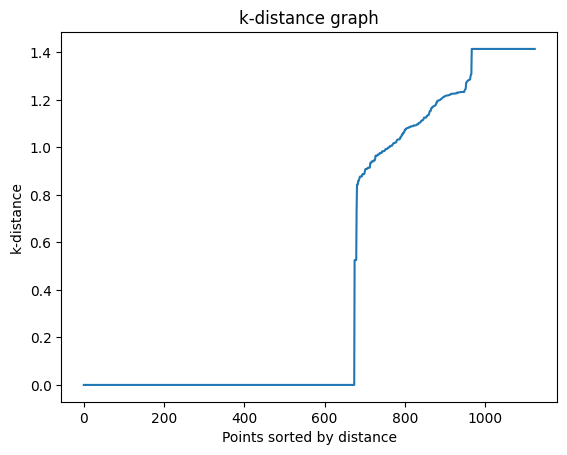

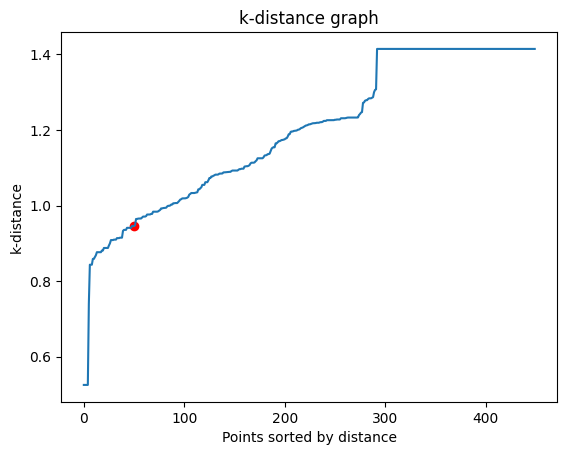

In [13]:
# !pip install kneed

import numpy as np
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
from kneed import KneeLocator

vectors = np.array([review['vectorized'].tolist() for review in combined_reviews])

# Step 1: Compute k-distance graph
k = 5
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(vectors)
distances, indices = neighbors_fit.kneighbors(vectors)

# Sort distances to plot the k-distance graph
distances = np.sort(distances[:, k-1], axis=0)
non_zero_distances = distances[distances > 0]

# Step 2: Use KneeLocator to find local maxima
kneedle = KneeLocator(range(len(non_zero_distances)), non_zero_distances, curve='convex', direction='increasing', online=True)
local_maxima_indices = list(kneedle.all_knees)

second_derivatives = np.diff(non_zero_distances, n=2)
local_maxima_indices = [i for i in local_maxima_indices if i < len(second_derivatives)]

# Find the index of the maximum second derivative among the local maximas
max_second_derivative_index = local_maxima_indices[np.argmax([second_derivatives[i] for i in local_maxima_indices])]

optimal_eps = non_zero_distances[max_second_derivative_index]
print(f"Optimal eps (x-axis): {max_second_derivative_index}")
print(f"Optimal eps (y-axis): {optimal_eps}")

# Step 2: Plot k-distance graph
plt.plot(distances)
plt.xlabel('Points sorted by distance')
plt.ylabel('k-distance')
plt.title('k-distance graph')
plt.show()

plt.plot(non_zero_distances)
plt.scatter(max_second_derivative_index, optimal_eps, color='red')
plt.xlabel('Points sorted by distance')
plt.ylabel('k-distance')
plt.title('k-distance graph')
plt.show()

<ipython-input-14-f298ac305688>:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap("tab20", len(unique_clusters))
<ipython-input-14-f298ac305688>:23: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f'Cluster {cluster}', s=5, c=color)


<Figure size 1000x600 with 0 Axes>

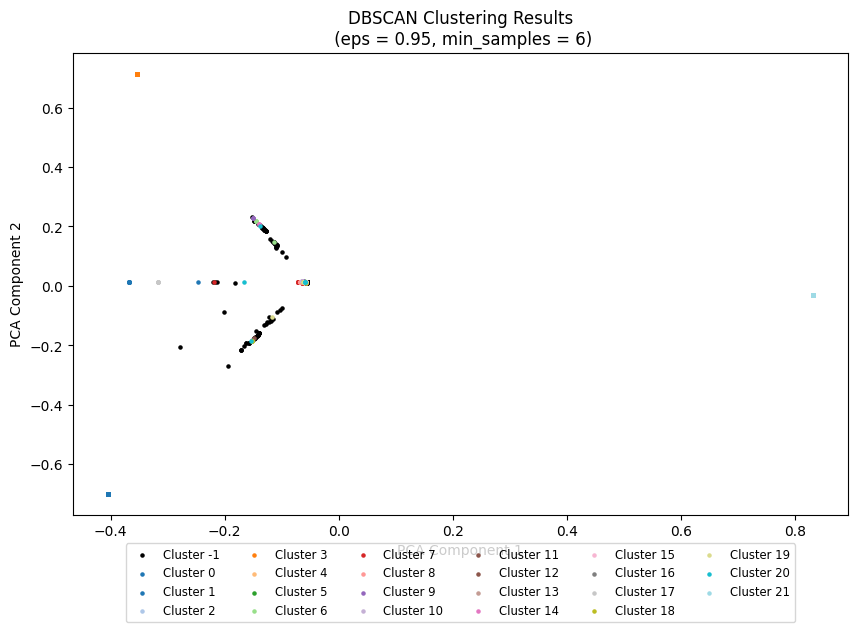

In [14]:
from sklearn.cluster import DBSCAN
min_samples=6
dbscan = DBSCAN(eps=optimal_eps, min_samples = min_samples)
clusters = dbscan.fit_predict(vectors)

# visualize clusters
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(vectors)

# Step 10: Visualize the results
unique_clusters = np.unique(clusters)

colors = plt.cm.get_cmap("tab20", len(unique_clusters))
# Plot the PCA-reduced data with cluster labels
plt.figure(figsize=(10, 6))
# Plot the PCA-reduced data with cluster labels
plt.figure(figsize=(10, 6))

for cluster in unique_clusters:
    cluster_points = X_pca[clusters == cluster]
    color = 'black' if cluster == -1 else colors(cluster)
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f'Cluster {cluster}', s=5, c=color)

plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title(f'DBSCAN Clustering Results\n (eps = {optimal_eps:.2f}, min_samples = {min_samples})')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=6, fontsize='small')
plt.show()